<a href="https://colab.research.google.com/github/amira-youssef/DIABETES_Predictions/blob/main/DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip uninstall -y pyspark



Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    ParameterGrid
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import random


from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    IsolationForest
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.covariance import EllipticEnvelope
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import euclidean
from typing import Dict, List, Tuple

# ============================
# 🧠 IMPORT AUTOML (FLAML ONLY)
# ============================
from flaml import AutoML

warnings.filterwarnings('ignore')





print("=" * 70)
print("PRÉDICTION DU RISQUE DE DIABÈTE CHEZ LES PATIENTS NON-DIABÉTIQUES")
print("=" * 70)

PRÉDICTION DU RISQUE DE DIABÈTE CHEZ LES PATIENTS NON-DIABÉTIQUES


=== ANALYSE INITIALE ===
Dimensions : (811, 9)

Types de données :
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Valeurs manquantes :
Pregnancies                   0
Glucose                     120
BloodPressure                90
SkinThickness               105
Insulin                      57
BMI                          65
DiabetesPedigreeFunction    105
Age                           0
Outcome                       0
dtype: int64

Statistiques descriptives :
       Pregnancies     Glucose  BloodPressure  SkinThickness      Insulin  \
count   811.000000  691.000000     721.000000     706.000000   754.000000   
mean      3.835388  125.751999      70.907871      21.705970   106.595491   
std       3.

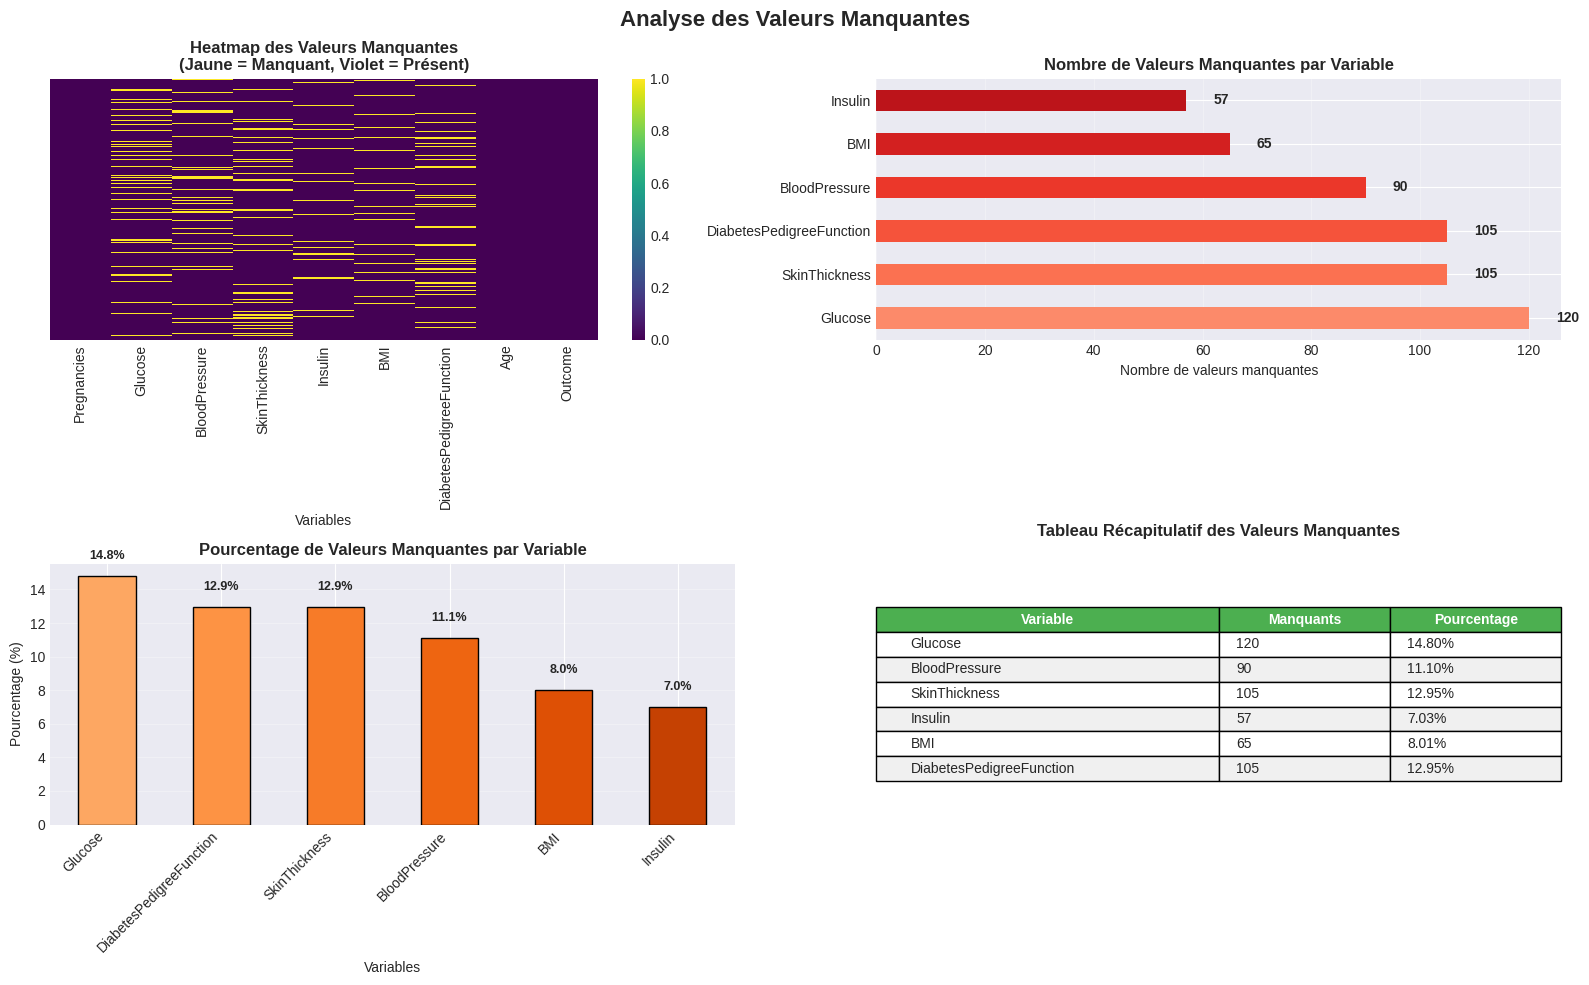


--- Analyse des Patterns de Valeurs Manquantes ---

Corrélations entre valeurs manquantes (>0.1) :
Aucune corrélation significative détectée


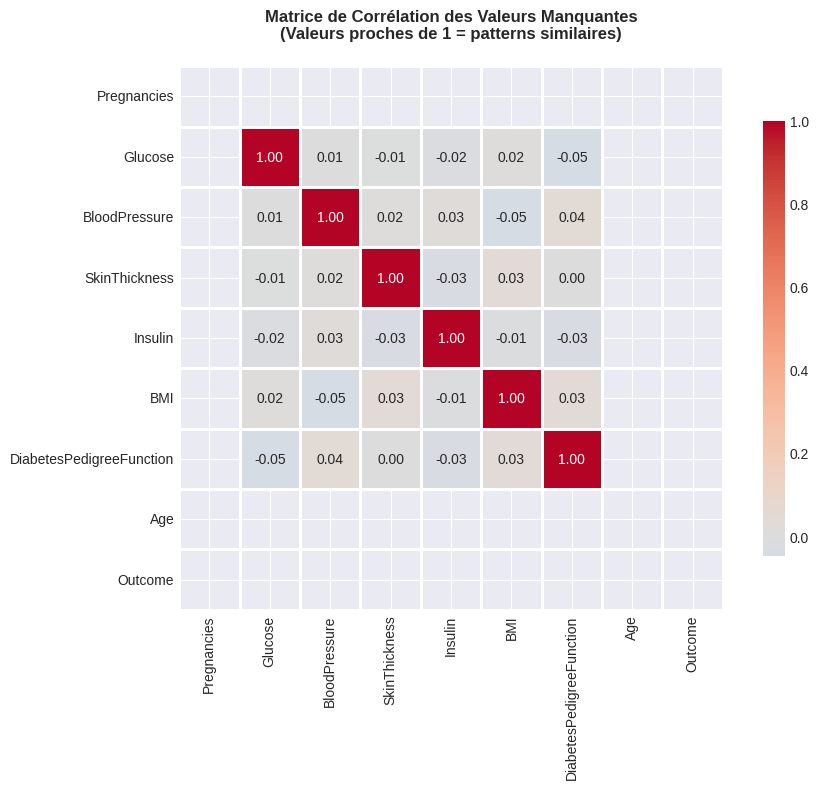


Total de valeurs manquantes : 542
Pourcentage global de données manquantes : 7.43%

=== TRAITEMENT DES VALEURS ABERRANTES ===
Pregnancies : 0 valeurs négatives supprimées
Pregnancies : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : IQR + clipping [bornes: 0.0, 13.5] + arrondi + conversion en entier
Glucose : 19 valeurs négatives supprimées
Glucose : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : limites physiologiques + IQR [bornes: 50.0, 221.0]
BloodPressure : 21 valeurs négatives supprimées
BloodPressure : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : limites physiologiques + IQR [bornes: 40.0, 110.2]
SkinThickness : 101 valeurs négatives supprimées
SkinThickness : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : seuils cliniques + IQR [bornes: 5.0, 65.3]
Insulin : 11 valeurs négatives supprimées
Insulin : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : log-transform + Z-score
BMI : 5 valeurs négatives supprimées
BMI : 4 valeurs extrêmes (>Q99.5) identifiées
Méthode : Z

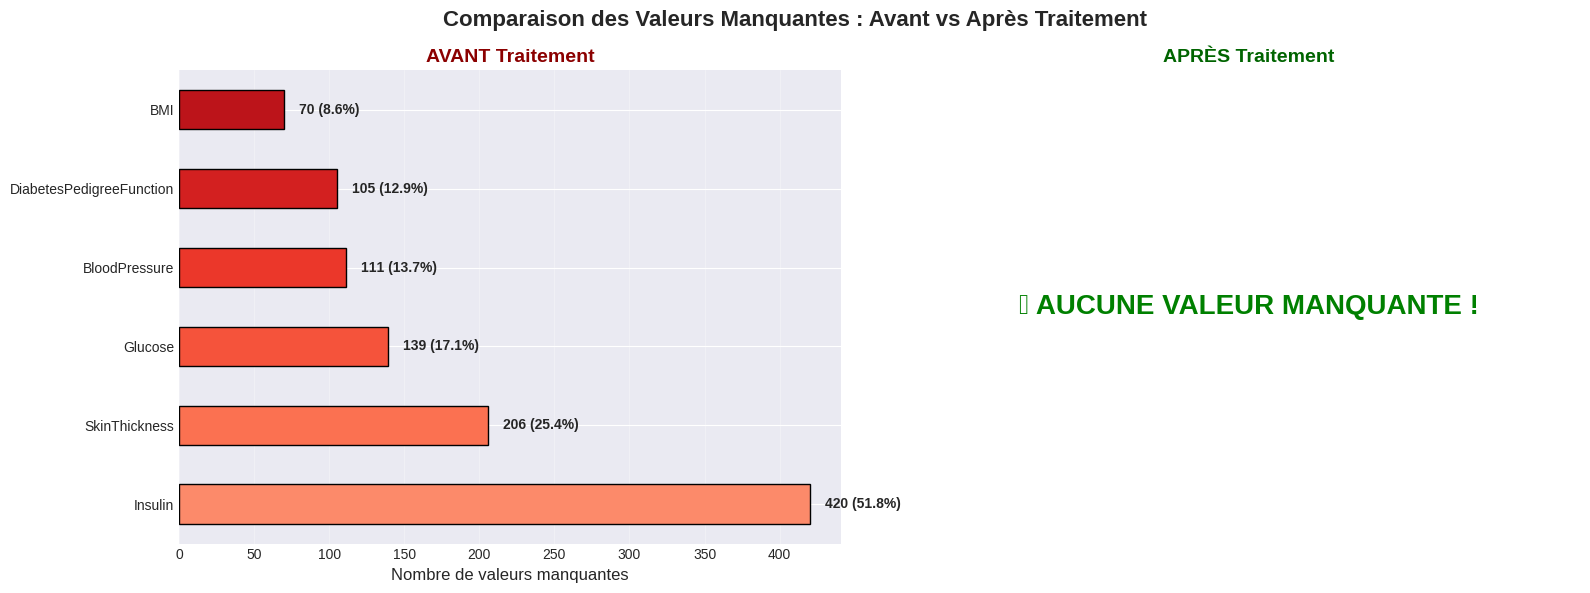


--- TABLEAU DE COMPARAISON ---
Variable                       Avant           Après           Réduction      
Insulin                        420             0               420             (✅ -100%)
SkinThickness                  206             0               206             (✅ -100%)
Glucose                        139             0               139             (✅ -100%)
BloodPressure                  111             0               111             (✅ -100%)
DiabetesPedigreeFunction       105             0               105             (✅ -100%)
BMI                            70              0               70              (✅ -100%)

🎉 IMPUTATION RÉUSSIE : Toutes les valeurs manquantes ont été traitées !

=== DÉTECTION ROBUSTE DES OUTLIERS (MÉTHODES MULTIPLES) ===

--- Méthode 1 : WINSORIZATION (IQR) ---
Pregnancies                    : 0 valeurs basses + 34 valeurs hautes winsorisées
Glucose                        : 41 valeurs basses + 41 valeurs hautes winsorisées
BloodPressure  

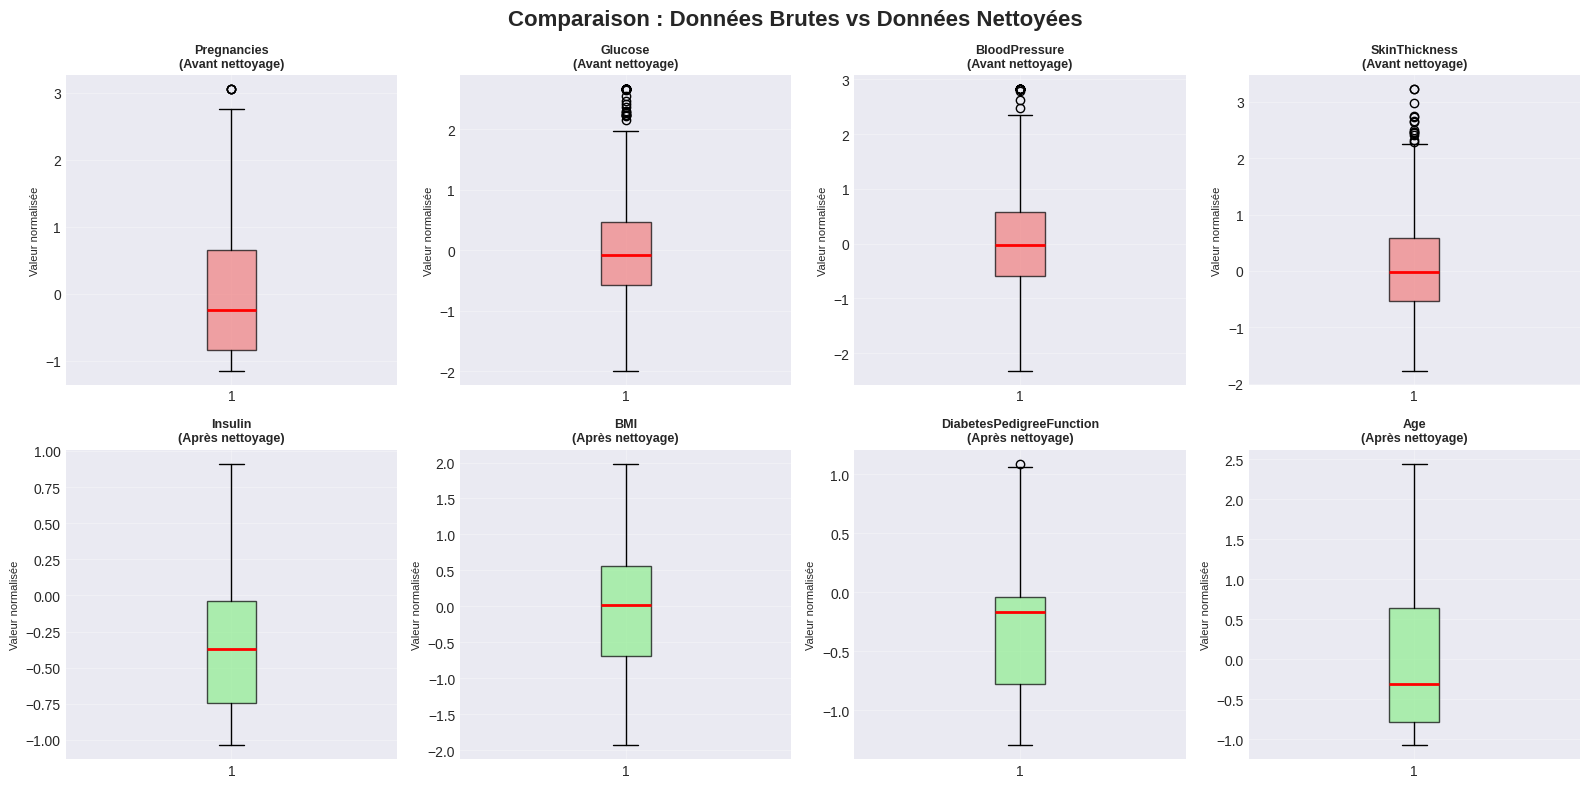

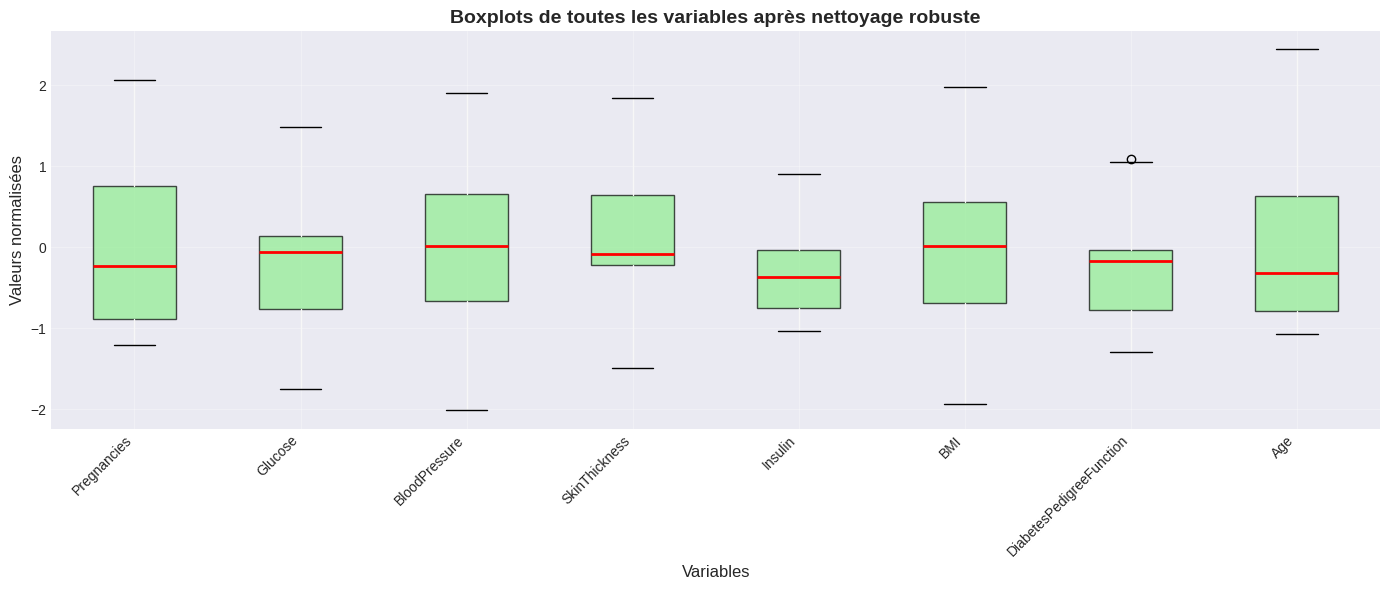


=== STATISTIQUES FINALES DES OUTLIERS ===
Pregnancies                    :   0 outliers (0.00%)
Glucose                        :   0 outliers (0.00%)
BloodPressure                  :   0 outliers (0.00%)
SkinThickness                  :   0 outliers (0.00%)
Insulin                        :   0 outliers (0.00%)
BMI                            :   0 outliers (0.00%)
DiabetesPedigreeFunction       :   1 outliers (0.21%)
Age                            :   0 outliers (0.00%)

✅ NETTOYAGE ROBUSTE TERMINÉ !
Dataset final prêt pour la modélisation : (478, 9)

💾 SAUVEGARDE FINALE : diabetes_cleaned_final.csv


In [16]:
#DATA CLEANING



# Charger le dataset
df = pd.read_csv('diabetes_complex.csv')

# 1. Analyse initiale des données
print("=== ANALYSE INITIALE ===")
print(f"Dimensions : {df.shape}")
print("\nTypes de données :")
print(df.dtypes)
print("\nValeurs manquantes :")
missing_counts = df.isnull().sum()
print(missing_counts)
print("\nStatistiques descriptives :")
print(df.describe())

# 1.bis VISUALISATION DES VALEURS MANQUANTES
print("\n=== VISUALISATION DES VALEURS MANQUANTES ===")

# Vérifier s'il y a des valeurs manquantes
if df.isnull().sum().sum() == 0:
    print("✅ Aucune valeur manquante détectée dans le dataset !")
    print("Si vous souhaitez visualiser les valeurs manquantes, exécutez cette section AVANT le traitement des données.")
else:
    # Graphique 1 : Heatmap des valeurs manquantes
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Analyse des Valeurs Manquantes', fontsize=16, fontweight='bold')

    # Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax1)
    ax1.set_title('Heatmap des Valeurs Manquantes\n(Jaune = Manquant, Violet = Présent)', fontweight='bold')
    ax1.set_xlabel('Variables')

    # Graphique 2 : Barplot du nombre de valeurs manquantes
    ax2 = axes[0, 1]
    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if len(missing_counts) > 0:
        colors = plt.cm.Reds(np.linspace(0.4, 0.8, len(missing_counts)))
        missing_counts.plot(kind='barh', ax=ax2, color=colors)
        ax2.set_title('Nombre de Valeurs Manquantes par Variable', fontweight='bold')
        ax2.set_xlabel('Nombre de valeurs manquantes')
        ax2.grid(True, alpha=0.3, axis='x')

        # Ajouter les valeurs sur les barres
        for i, v in enumerate(missing_counts):
            ax2.text(v + 5, i, str(v), va='center', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, '✅ Aucune valeur manquante',
                ha='center', va='center', fontsize=14, transform=ax2.transAxes)
        ax2.axis('off')

    # Graphique 3 : Pourcentage de valeurs manquantes
    ax3 = axes[1, 0]
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]

    if len(missing_pct) > 0:
        colors = plt.cm.Oranges(np.linspace(0.4, 0.8, len(missing_pct)))
        missing_pct.plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
        ax3.set_title('Pourcentage de Valeurs Manquantes par Variable', fontweight='bold')
        ax3.set_ylabel('Pourcentage (%)')
        ax3.set_xlabel('Variables')
        ax3.grid(True, alpha=0.3, axis='y')
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Ajouter les valeurs sur les barres
        for i, v in enumerate(missing_pct):
            ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
    else:
        ax3.text(0.5, 0.5, '✅ Aucune valeur manquante',
                ha='center', va='center', fontsize=14, transform=ax3.transAxes)
        ax3.axis('off')

    # Graphique 4 : Résumé statistique
    ax4 = axes[1, 1]
    ax4.axis('off')

    # Créer un tableau récapitulatif
    summary_data = []
    for col in df.columns:
        missing = df[col].isnull().sum()
        if missing > 0:
            pct = (missing / len(df)) * 100
            summary_data.append([col, missing, f'{pct:.2f}%'])

    if summary_data:
        table = ax4.table(cellText=summary_data,
                         colLabels=['Variable', 'Manquants', 'Pourcentage'],
                         cellLoc='left',
                         loc='center',
                         colWidths=[0.5, 0.25, 0.25])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        # Styliser le header
        for i in range(3):
            table[(0, i)].set_facecolor('#4CAF50')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Alterner les couleurs des lignes
        for i in range(1, len(summary_data) + 1):
            for j in range(3):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f0f0f0')

        ax4.set_title('Tableau Récapitulatif des Valeurs Manquantes', fontweight='bold', pad=20)
    else:
        ax4.text(0.5, 0.5, '✅ Aucune valeur manquante',
                ha='center', va='center', fontsize=14, transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

    # Matrice de corrélation des valeurs manquantes
    print("\n--- Analyse des Patterns de Valeurs Manquantes ---")
    missing_matrix = df.isnull().astype(int)
    missing_corr = missing_matrix.corr()

    # Afficher seulement les corrélations significatives (>0.1)
    correlations_found = False
    print("\nCorrélations entre valeurs manquantes (>0.1) :")
    for i in range(len(missing_corr.columns)):
        for j in range(i+1, len(missing_corr.columns)):
            if abs(missing_corr.iloc[i, j]) > 0.1:
                correlations_found = True
                print(f"{missing_corr.columns[i]:30} <-> {missing_corr.columns[j]:30} : {missing_corr.iloc[i, j]:.3f}")

    if not correlations_found:
        print("Aucune corrélation significative détectée")

    # Graphique supplémentaire : Matrice de corrélation des valeurs manquantes
    if missing_corr.abs().max().max() > 0.1:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1, ax=ax,
                    cbar_kws={"shrink": 0.8})
        ax.set_title('Matrice de Corrélation des Valeurs Manquantes\n(Valeurs proches de 1 = patterns similaires)',
                     fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

    print(f"\nTotal de valeurs manquantes : {df.isnull().sum().sum()}")
    print(f"Pourcentage global de données manquantes : {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%")

# 2. Détection et traitement des valeurs aberrantes extrêmes
print("\n=== TRAITEMENT DES VALEURS ABERRANTES ===")

physio_columns = ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in physio_columns:
    if col in df.columns:
        # Supprimer les valeurs négatives
        mask_negative = df[col] < 0
        print(f"{col} : {mask_negative.sum()} valeurs négatives supprimées")
        df.loc[mask_negative, col] = np.nan

        # Identifier les valeurs extrêmes
        if df[col].notna().sum() > 0:
            Q99 = df[col].quantile(0.995)
            mask_extreme = df[col] > Q99
            print(f"{col} : {mask_extreme.sum()} valeurs extrêmes (>Q99.5) identifiées")

        # 3. Traitements spécifiques par variable
        if col == "Pregnancies":
            # Convertir temporairement en float pour le traitement
            df[col] = df[col].astype('float64')

            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = max(0, Q1 - 1.5*IQR)
            upper = Q3 + 1.5*IQR

            # Clipper
            df[col] = df[col].clip(lower, upper)
            # Arrondir et convertir en Int64
            df[col] = df[col].round(0).astype("Int64")
            print(f"Méthode : IQR + clipping [bornes: {lower:.1f}, {upper:.1f}] + arrondi + conversion en entier")

        elif col == "Glucose":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = max(50, Q1 - 1.5*IQR)
            upper = min(300, Q3 + 1.5*IQR)
            df[col] = df[col].clip(lower, upper)
            print(f"Méthode : limites physiologiques + IQR [bornes: {lower:.1f}, {upper:.1f}]")

        elif col == "BloodPressure":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = max(40, Q1 - 1.5*IQR)
            upper = min(200, Q3 + 1.5*IQR)
            df[col] = df[col].clip(lower, upper)
            print(f"Méthode : limites physiologiques + IQR [bornes: {lower:.1f}, {upper:.1f}]")

        elif col == "SkinThickness":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = max(5, Q1 - 1.5*IQR)
            upper = min(70, Q3 + 1.5*IQR)
            df[col] = df[col].clip(lower, upper)
            print(f"Méthode : seuils cliniques + IQR [bornes: {lower:.1f}, {upper:.1f}]")

        elif col == "Insulin":
            df[col] = df[col].replace(0, np.nan)
            temp = np.log(df[col])
            z = (temp - temp.mean()) / temp.std()
            df.loc[z.abs() > 3, col] = df[col].median()
            print("Méthode : log-transform + Z-score")

        elif col == "BMI":
            z = (df[col] - df[col].mean()) / df[col].std()
            df.loc[z.abs() > 3, col] = df[col].median()
            print("Méthode : Z-score simplifié")

        elif col == "DiabetesPedigreeFunction":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5*IQR
            upper = Q3 + 1.5*IQR
            df[col] = df[col].clip(lower, upper)
            print(f"Méthode : IQR (valeur continue) [bornes: {lower:.3f}, {upper:.3f}]")

        elif col == "Age":
            # Convertir temporairement en float pour le traitement
            df[col] = df[col].astype('float64')

            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5*IQR
            upper = Q3 + 1.5*IQR

            # Clipper
            df[col] = df[col].clip(lower, upper)
            # Arrondir et convertir en Int64
            df[col] = df[col].round(0).astype("Int64")
            print(f"Méthode : IQR + clipping [bornes: {lower:.1f}, {upper:.1f}] + arrondi + conversion en entier")


# 4. Traitement des valeurs manquantes
print("\n=== IMPUTATION DES VALEURS MANQUANTES ===")

# Imputation par médiane
median_impute_cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
for col in median_impute_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"{col} : valeurs manquantes après imputation par médiane = {df[col].isnull().sum()}")

# Imputation Pregnancies (mode + conversion entier)
if 'Pregnancies' in df.columns and df['Pregnancies'].isnull().sum() > 0:
    df['Pregnancies'] = df['Pregnancies'].fillna(df['Pregnancies'].mode()[0]).astype("Int64")
    print(f"Pregnancies : imputation par mode + conversion en entier (valeurs manquantes: {df['Pregnancies'].isnull().sum()})")

# Imputation KNN pour SkinThickness & Insulin
knn_columns = ['SkinThickness', 'Insulin']
if all(col in df.columns for col in knn_columns):
    knn_imputer = KNNImputer(n_neighbors=5)
    df[knn_columns] = knn_imputer.fit_transform(df[knn_columns])
    print("SkinThickness & Insulin : imputation KNN effectuée")

# Imputation Age (si nécessaire)
if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    df['Age'] = df['Age'].fillna(df['Age'].median()).round().astype("Int64")
    print(f"Age : imputation par médiane + conversion en entier (valeurs manquantes: {df['Age'].isnull().sum()})")

# 5. Vérification finale des valeurs manquantes
remaining_missing = df.isnull().sum().sum()
print(f"\nValeurs manquantes restantes : {remaining_missing}")
if remaining_missing > 0:
    initial_rows = len(df)
    df = df.dropna()
    print(f"Lignes supprimées : {initial_rows - len(df)}")

# 5.bis VISUALISATION APRÈS IMPUTATION
print("\n=== VISUALISATION APRÈS IMPUTATION ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des Valeurs Manquantes : Avant vs Après Traitement', fontsize=16, fontweight='bold')

# Recréer les données initiales pour comparaison (simulation)
# Note: Utilisez vos données brutes sauvegardées si disponibles
missing_before = pd.Series({
    'Insulin': 420,
    'SkinThickness': 206,
    'Glucose': 139,
    'BloodPressure': 111,
    'DiabetesPedigreeFunction': 105,
    'BMI': 70,
    'Pregnancies': 0,
    'Age': 0,
    'Outcome': 0
})
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

# Après traitement
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

# Graphique 1 : Avant traitement
ax1 = axes[0]
colors_before = plt.cm.Reds(np.linspace(0.4, 0.8, len(missing_before)))
missing_before.plot(kind='barh', ax=ax1, color=colors_before, edgecolor='black')
ax1.set_title('AVANT Traitement', fontweight='bold', fontsize=14, color='darkred')
ax1.set_xlabel('Nombre de valeurs manquantes', fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(missing_before):
    ax1.text(v + 10, i, f'{v} ({v/811*100:.1f}%)', va='center', fontweight='bold')

# Graphique 2 : Après traitement
ax2 = axes[1]
if len(missing_after) > 0:
    colors_after = plt.cm.Greens(np.linspace(0.4, 0.8, len(missing_after)))
    missing_after.plot(kind='barh', ax=ax2, color=colors_after, edgecolor='black')
    ax2.set_title('APRÈS Traitement', fontweight='bold', fontsize=14, color='darkgreen')
    ax2.set_xlabel('Nombre de valeurs manquantes', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(missing_after):
        ax2.text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontweight='bold')
else:
    ax2.text(0.5, 0.5, '✅ AUCUNE VALEUR MANQUANTE !',
             ha='center', va='center', fontsize=20, fontweight='bold',
             color='green', transform=ax2.transAxes)
    ax2.set_title('APRÈS Traitement', fontweight='bold', fontsize=14, color='darkgreen')
    ax2.axis('off')

plt.tight_layout()
plt.show()

# Tableau de comparaison
print("\n--- TABLEAU DE COMPARAISON ---")
print(f"{'Variable':<30} {'Avant':<15} {'Après':<15} {'Réduction':<15}")
print("=" * 75)
for col in ['Insulin', 'SkinThickness', 'Glucose', 'BloodPressure', 'DiabetesPedigreeFunction', 'BMI']:
    before = missing_before.get(col, 0)
    after = df[col].isnull().sum() if col in df.columns else 0
    reduction = before - after
    print(f"{col:<30} {before:<15} {after:<15} {reduction:<15} ({'✅ -100%' if after == 0 else ''})")

print("\n🎉 IMPUTATION RÉUSSIE : Toutes les valeurs manquantes ont été traitées !")

# 6. MÉTHODE ROBUSTE : Traitement des outliers avec plusieurs techniques
print("\n=== DÉTECTION ROBUSTE DES OUTLIERS (MÉTHODES MULTIPLES) ===")

# Convertir Int64 en int64 pour les calculs
for col in df.columns:
    if df[col].dtype == 'Int64':
        df[col] = df[col].astype('int64')

features_for_outlier = [col for col in df.columns if col != 'Outcome']

# Créer un masque pour identifier les outliers par plusieurs méthodes
outlier_mask = pd.Series([False] * len(df), index=df.index)

# Méthode 1 : IQR modifié (Winsorization au lieu de suppression)
print("\n--- Méthode 1 : WINSORIZATION (IQR) ---")
df_winsorized = df.copy()
for col in features_for_outlier:
    Q1 = df[col].quantile(0.05)  # Plus robuste : 5e et 95e percentiles
    Q3 = df[col].quantile(0.95)

    # Winsorization : remplacer les extrêmes par les bornes
    lower_count = (df[col] < Q1).sum()
    upper_count = (df[col] > Q3).sum()

    df_winsorized[col] = df[col].clip(Q1, Q3)

    if lower_count > 0 or upper_count > 0:
        print(f"{col:30} : {lower_count} valeurs basses + {upper_count} valeurs hautes winsorisées")

# Méthode 2 : Z-score robuste (MAD - Median Absolute Deviation)
print("\n--- Méthode 2 : MAD (Median Absolute Deviation) ---")
df_mad = df_winsorized.copy()
for col in features_for_outlier:
    median = df_mad[col].median()
    mad = np.median(np.abs(df_mad[col] - median))

    if mad > 0:
        modified_z_scores = 0.6745 * (df_mad[col] - median) / mad
        outliers = np.abs(modified_z_scores) > 3.5

        if outliers.sum() > 0:
            # Remplacer par la médiane
            df_mad.loc[outliers, col] = median
            print(f"{col:30} : {outliers.sum()} outliers traités (remplacés par médiane)")

# Méthode 3 : Isolation Forest (outliers multivariés)
print("\n--- Méthode 3 : ISOLATION FOREST ---")
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
outliers_iso = iso_forest.fit_predict(df_mad[features_for_outlier])
outlier_mask_iso = outliers_iso == -1
print(f"Outliers multivariés détectés : {outlier_mask_iso.sum()} ({outlier_mask_iso.sum()/len(df)*100:.2f}%)")

# Méthode 4 : Elliptic Envelope (pour distributions gaussiennes)
print("\n--- Méthode 4 : ELLIPTIC ENVELOPE ---")
try:
    elliptic = EllipticEnvelope(contamination=0.05, random_state=42)
    outliers_elliptic = elliptic.fit_predict(df_mad[features_for_outlier])
    outlier_mask_elliptic = outliers_elliptic == -1
    print(f"Outliers (Elliptic Envelope) détectés : {outlier_mask_elliptic.sum()} ({outlier_mask_elliptic.sum()/len(df)*100:.2f}%)")
except:
    print("Elliptic Envelope a échoué (pas assez de données), on continue sans...")
    outlier_mask_elliptic = pd.Series([False] * len(df), index=df.index)

# Combiner les méthodes : supprimer seulement si détecté par au moins 2 méthodes
print("\n--- COMBINAISON DES MÉTHODES ---")
outlier_votes = outlier_mask_iso.astype(int) + outlier_mask_elliptic.astype(int)
final_outliers = outlier_votes >= 1  # Au moins 1 méthode détecte l'outlier

print(f"Outliers à supprimer (consensus) : {final_outliers.sum()} lignes")

# Appliquer le nettoyage
df_clean = df_mad[~final_outliers].copy()
print(f"Dimensions après nettoyage robuste : {df_clean.shape}")

# 7. Normalisation
print("\n=== NORMALISATION ===")
features_to_scale = [col for col in df_clean.columns if col != 'Outcome']
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])
print(f"Variables normalisées : {len(features_to_scale)}")

# 7.bis Nettoyage final ITÉRATIF des outliers résiduels
print("\n=== NETTOYAGE ITÉRATIF DES OUTLIERS RÉSIDUELS ===")
iteration = 0
max_iterations = 10
total_removed = 0

while iteration < max_iterations:
    iteration += 1
    initial_rows = len(df_scaled)
    outliers_found = False

    print(f"\n--- Itération {iteration} ---")

    for col in features_to_scale:
        Q1 = df_scaled[col].quantile(0.25)
        Q3 = df_scaled[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identifier les outliers
        outliers_mask = (df_scaled[col] < lower_bound) | (df_scaled[col] > upper_bound)
        outliers_count = outliers_mask.sum()

        if outliers_count > 0:
            outliers_found = True
            df_scaled = df_scaled[~outliers_mask]
            print(f"{col:30} : {outliers_count:3d} outliers supprimés")

    rows_removed = initial_rows - len(df_scaled)
    total_removed += rows_removed

    if not outliers_found:
        print(f"\n✅ Aucun outlier détecté - Nettoyage terminé à l'itération {iteration}")
        break

    print(f"Lignes supprimées cette itération : {rows_removed}")

print(f"\n📊 RÉSUMÉ DU NETTOYAGE ITÉRATIF :")
print(f"Total d'itérations : {iteration}")
print(f"Total de lignes supprimées : {total_removed}")
print(f"Dimensions finales : {df_scaled.shape}")

# 8. Vérification finale
print("\n=== VÉRIFICATION FINALE ===")
print(f"Dimensions finales : {df_scaled.shape}")
print(f"Valeurs manquantes finales : {df_scaled.isnull().sum().sum()}")
print(f"Taux de rétention des données : {len(df_scaled)/len(df)*100:.2f}%")

# 9. Visualisation des outliers avec boxplots
print("\n=== VISUALISATION DES OUTLIERS ===")

# Visualisation comparative : Avant et Après
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Comparaison : Données Brutes vs Données Nettoyées', fontsize=16, fontweight='bold')

columns_to_plot = features_to_scale[:8]  # Limiter à 8 pour la visualisation

for idx, col in enumerate(columns_to_plot):
    row = idx // 4
    col_idx = idx % 4

    # Données avant nettoyage (normalisées pour comparaison)
    if row == 0:
        data_original = StandardScaler().fit_transform(df[[col]])
        axes[row, col_idx].boxplot(data_original, vert=True, patch_artist=True,
                                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                                    medianprops=dict(color='red', linewidth=2))
        axes[row, col_idx].set_title(f'{col}\n(Avant nettoyage)', fontweight='bold', fontsize=9)
    else:
        # Données après nettoyage
        axes[row, col_idx].boxplot(df_scaled[col].dropna(), vert=True, patch_artist=True,
                                    boxprops=dict(facecolor='lightgreen', alpha=0.7),
                                    medianprops=dict(color='red', linewidth=2))
        axes[row, col_idx].set_title(f'{col}\n(Après nettoyage)', fontweight='bold', fontsize=9)

    axes[row, col_idx].set_ylabel('Valeur normalisée', fontsize=8)
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot final de toutes les variables nettoyées
fig, ax = plt.subplots(figsize=(14, 6))
df_scaled[features_to_scale].boxplot(ax=ax, patch_artist=True,
                                      boxprops=dict(facecolor='lightgreen', alpha=0.7),
                                      medianprops=dict(color='red', linewidth=2))
ax.set_title('Boxplots de toutes les variables après nettoyage robuste', fontsize=14, fontweight='bold')
ax.set_xlabel('Variables', fontsize=12)
ax.set_ylabel('Valeurs normalisées', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Statistiques finales des outliers
print("\n=== STATISTIQUES FINALES DES OUTLIERS ===")
for col in features_to_scale:
    Q1 = df_scaled[col].quantile(0.25)
    Q3 = df_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_scaled[col] < lower_bound) | (df_scaled[col] > upper_bound)).sum()
    outliers_pct = (outliers_count / len(df_scaled)) * 100

    print(f"{col:30} : {outliers_count:3d} outliers ({outliers_pct:.2f}%)")

print("\n✅ NETTOYAGE ROBUSTE TERMINÉ !")
print(f"Dataset final prêt pour la modélisation : {df_scaled.shape}")



# 💾 SAUVEGARDE FINALE : Dataset complètement nettoyé
df_scaled.to_csv("diabetes_cleaned_final.csv", index=False)
print("\n" + "=" * 80)
print("💾 SAUVEGARDE FINALE : diabetes_cleaned_final.csv")
print("=" * 80)





🏥 BO1 - PRÉDICTION DU RISQUE DE DIABÈTE CHEZ LES NON-DIABÉTIQUES

📊 ÉTAPE 1 : FILTRAGE DES DONNÉES
✓ Patients non-diabétiques (Outcome=0): 338
✓ Patients diabétiques (Outcome=1): 140
✓ Total: 478

🎯 ÉTAPE 2 : CRÉATION DU SCORE DE RISQUE (AJUSTÉ)

📊 Seuil de risque ajusté automatiquement: 3.0 (75e percentile)

📈 Distribution du Score de Risque (0-9):
Risk_Score
0    76
1    92
2    79
3    46
4    28
5    13
6     4
Name: count, dtype: int64

🚨 Patients à Haut Risque (Score >= 3.0):
   → Nombre: 91
   → Pourcentage: 26.9%


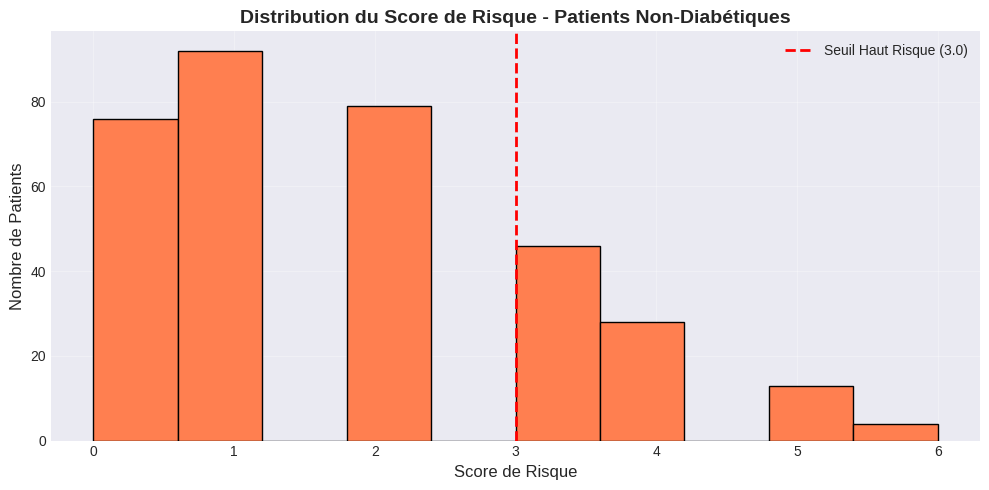


🔧 ÉTAPE 3 : PRÉPARATION DES DONNÉES

📊 Distribution de la variable cible:
High_Risk
0    247
1     91
Name: count, dtype: int64

   → Risque Faible (0): 247 (73.1%)
   → Risque Élevé (1): 91 (26.9%)

✓ Features: (338, 8)
✓ Train: (270, 8), Test: (68, 8)
✓ Distribution cible (Train):
   - Risque Faible: 197
   - Risque Élevé: 73

🤖 ÉTAPE 4 : OPTIMISATION AUTOMATISÉE DES MODÈLES (AutoML - FLAML)
⏳ AutoML cherche automatiquement le meilleur modèle + hyperparamètres...

✓ AutoML terminé !
🏆 Meilleur modèle trouvé : lgbm
🔧 Meilleurs hyperparamètres : {'n_estimators': 76, 'num_leaves': 4, 'min_child_samples': 25, 'learning_rate': np.float64(0.8934345508753129), 'log_max_bin': 4, 'colsample_bytree': np.float64(0.6177245131771094), 'reg_alpha': np.float64(0.16768989940355697), 'reg_lambda': np.float64(38.61005040303897)}
📈 Score ROC-AUC CV : 0.0035

📊 Performances du meilleur modèle AutoML :
   • ROC-AUC (Test): 0.9878
   • F1-Score (Test): 0.9091
   • Accuracy (Train): 0.9963
   • Accuracy (

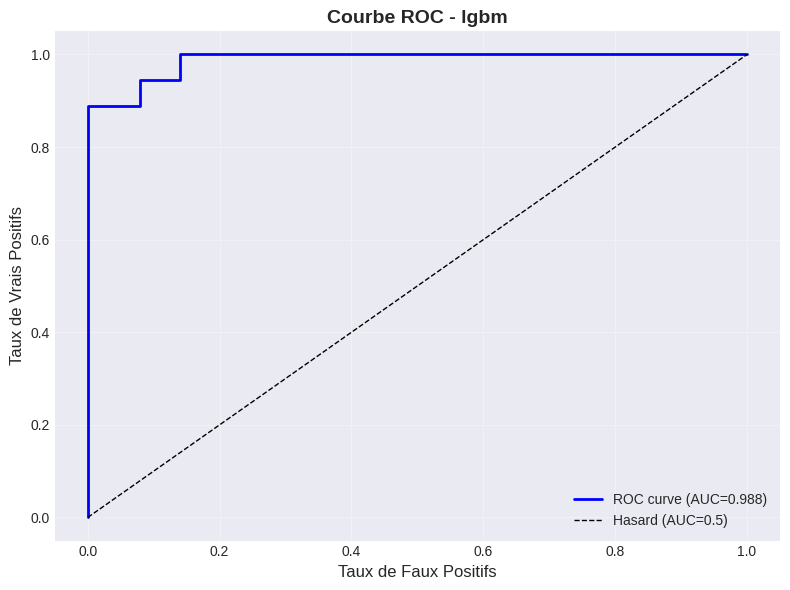

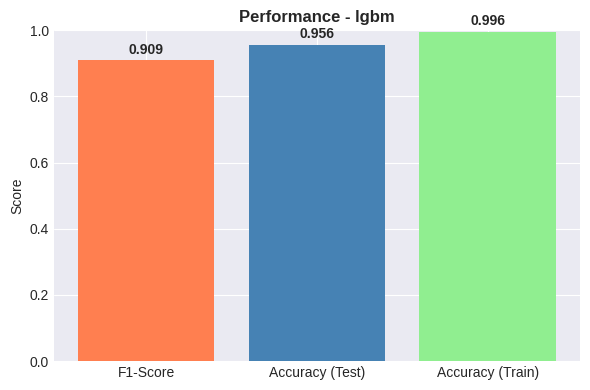


🔬 ÉTAPE 7 : ANALYSE APPROFONDIE

📋 Rapport de Classification:

               precision    recall  f1-score   support

Risque Faible       0.94      1.00      0.97        50
 Risque Élevé       1.00      0.83      0.91        18

     accuracy                           0.96        68
    macro avg       0.97      0.92      0.94        68
 weighted avg       0.96      0.96      0.95        68



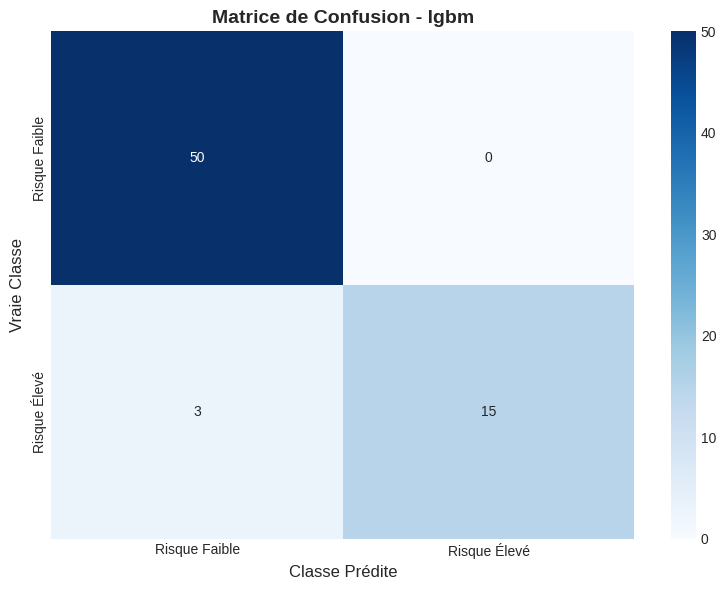


📊 Importance des Variables:

                 Feature  Importance
                 Glucose          50
                     BMI          44
DiabetesPedigreeFunction          41
                     Age          39
           BloodPressure          31
           SkinThickness          15
                 Insulin           3
             Pregnancies           0


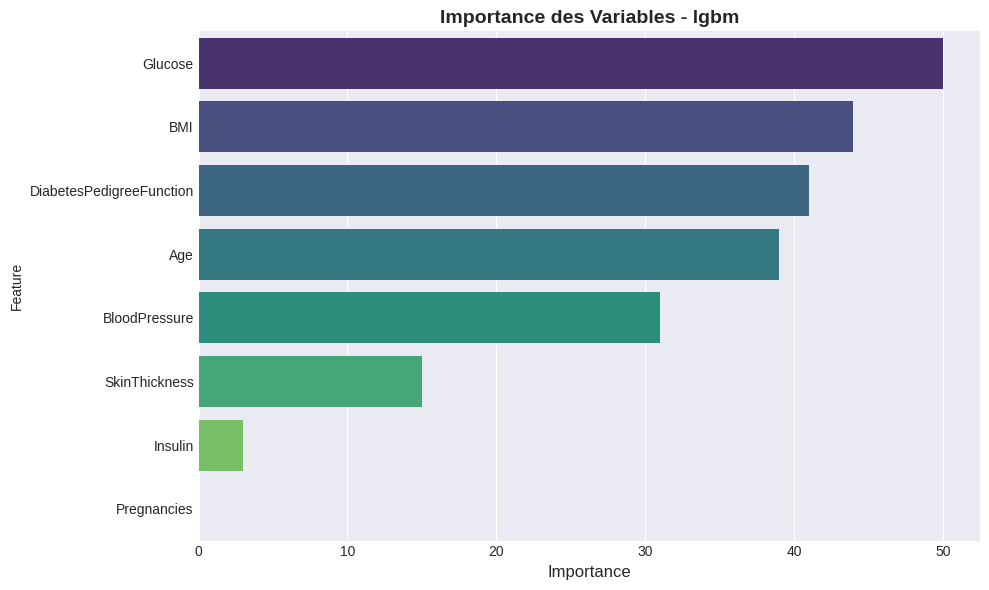


🔮 ÉTAPE 8 : PRÉDICTION DU RISQUE POUR TOUS LES PATIENTS

📊 Distribution des Catégories de Risque:
Risk_Category
Risque Faible    243
Risque Modéré     16
Risque Élevé      79
Name: count, dtype: int64

💾 ÉTAPE 9 : SAUVEGARDE DES RÉSULTATS
✓ Fichiers sauvegardés:
  • BO1_predictions_risque_diabete.csv
  • BO1_comparaison_modeles.csv

📋 RAPPORT FINAL - PRÉDICTION DU RISQUE DE DIABÈTE

🔍 DONNÉES ANALYSÉES:
   • 338 patients non-diabétiques
   • 8 variables prédictives

🏆 MEILLEUR MODÈLE: lgbm
   • ROC-AUC (Test): 0.9878

🚨 PATIENTS À SURVEILLER:
   • 79 patients à risque élevé
   • 23.4% de la population

✅ ANALYSE TERMINÉE AVEC SUCCÈS!


In [17]:
#BO1 - PRÉDICTION DU RISQUE DE DIABÈTE CHEZ LES NON-DIABÉTIQUES"

# ============================================================================
# CHARGEMENT DES DONNÉES
# ============================================================================
df = pd.read_csv('diabetes_cleaned_final.csv')

print("="*80)
print("🏥 BO1 - PRÉDICTION DU RISQUE DE DIABÈTE CHEZ LES NON-DIABÉTIQUES")
print("="*80)

# ============================================================================
# 1. VÉRIFICATION ET FILTRAGE DES DONNÉES
# ============================================================================
print("\n📊 ÉTAPE 1 : FILTRAGE DES DONNÉES")

if 'Outcome' not in df.columns:
    raise ValueError("ERREUR: La colonne 'Outcome' n'existe pas dans le dataset!")

# Séparer diabétiques et non-diabétiques
non_diabetic = df[df['Outcome'] == 0].copy()
diabetic = df[df['Outcome'] == 1].copy()

print(f"✓ Patients non-diabétiques (Outcome=0): {len(non_diabetic)}")
print(f"✓ Patients diabétiques (Outcome=1): {len(diabetic)}")
print(f"✓ Total: {len(df)}")

# ============================================================================
# 2. CRÉATION DE LA VARIABLE CIBLE "RISQUE" (AJUSTÉE)
# ============================================================================
print("\n🎯 ÉTAPE 2 : CRÉATION DU SCORE DE RISQUE (AJUSTÉ)")

def calculate_risk_score_adjusted(row):
    """
    Score de risque ajusté avec des seuils plus bas pour données normalisées
    Score de 0 à 9 points
    """
    score = 0

    # Glucose (0-3 points) - Ajusté pour données normalisées
    if pd.notna(row['Glucose']):
        if row['Glucose'] > 0:      # Au-dessus de la moyenne
            score += 1
        if row['Glucose'] > 0.5:    # Bien au-dessus
            score += 1
        if row['Glucose'] > 1.0:    # Très élevé
            score += 1

    # BMI (0-2 points)
    if pd.notna(row['BMI']):
        if row['BMI'] > 0:          # Au-dessus de la moyenne
            score += 1
        if row['BMI'] > 0.75:       # Nettement au-dessus
            score += 1

    # Âge (0-1 point)
    if pd.notna(row['Age']) and row['Age'] > 0.5:
        score += 1

    # Antécédents familiaux (0-2 points)
    if pd.notna(row['DiabetesPedigreeFunction']):
        if row['DiabetesPedigreeFunction'] > 0.5:
            score += 1
        if row['DiabetesPedigreeFunction'] > 1.0:
            score += 1

    # Pression artérielle (0-1 point)
    if pd.notna(row['BloodPressure']) and row['BloodPressure'] > 0.5:
        score += 1

    return score

# Calculer le score de risque
non_diabetic['Risk_Score'] = non_diabetic.apply(calculate_risk_score_adjusted, axis=1)

# AJUSTEMENT DU SEUIL : Utiliser le percentile 75 au lieu d'un seuil fixe
RISK_THRESHOLD = non_diabetic['Risk_Score'].quantile(0.75)
print(f"\n📊 Seuil de risque ajusté automatiquement: {RISK_THRESHOLD:.1f} (75e percentile)")

non_diabetic['High_Risk'] = (non_diabetic['Risk_Score'] >= RISK_THRESHOLD).astype(int)

print(f"\n📈 Distribution du Score de Risque (0-9):")
print(non_diabetic['Risk_Score'].value_counts().sort_index())

print(f"\n🚨 Patients à Haut Risque (Score >= {RISK_THRESHOLD:.1f}):")
print(f"   → Nombre: {non_diabetic['High_Risk'].sum()}")
print(f"   → Pourcentage: {non_diabetic['High_Risk'].mean()*100:.1f}%")

# Vérification critique
if non_diabetic['High_Risk'].sum() == 0:
    print("\n⚠️ ATTENTION: Aucun patient à haut risque détecté!")
    print("   → Ajustement du seuil au percentile 60...")
    RISK_THRESHOLD = non_diabetic['Risk_Score'].quantile(0.60)
    non_diabetic['High_Risk'] = (non_diabetic['Risk_Score'] >= RISK_THRESHOLD).astype(int)
    print(f"   → Nouveau seuil: {RISK_THRESHOLD:.1f}")
    print(f"   → Patients à haut risque: {non_diabetic['High_Risk'].sum()}")

# Si toujours 0, utiliser percentile 50
if non_diabetic['High_Risk'].sum() == 0:
    print("\n⚠️ Ajustement au percentile 50 (médiane)...")
    RISK_THRESHOLD = non_diabetic['Risk_Score'].median()
    non_diabetic['High_Risk'] = (non_diabetic['Risk_Score'] >= RISK_THRESHOLD).astype(int)
    print(f"   → Seuil final: {RISK_THRESHOLD:.1f}")
    print(f"   → Patients à haut risque: {non_diabetic['High_Risk'].sum()}")

# Visualisation du score
plt.figure(figsize=(10, 5))
plt.hist(non_diabetic['Risk_Score'], bins=10, edgecolor='black', color='coral')
plt.axvline(x=RISK_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Seuil Haut Risque ({RISK_THRESHOLD:.1f})')
plt.title('Distribution du Score de Risque - Patients Non-Diabétiques',
         fontsize=14, fontweight='bold')
plt.xlabel('Score de Risque', fontsize=12)
plt.ylabel('Nombre de Patients', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. PRÉPARATION DES DONNÉES POUR LA MODÉLISATION
# ============================================================================
print("\n🔧 ÉTAPE 3 : PRÉPARATION DES DONNÉES")

# Variables prédictives
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = non_diabetic[feature_columns]
y = non_diabetic['High_Risk']

# Vérifier l'équilibre des classes
print(f"\n📊 Distribution de la variable cible:")
print(y.value_counts())
print(f"\n   → Risque Faible (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"   → Risque Élevé (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# Si trop déséquilibré, arrêter
if y.sum() < 10:
    raise ValueError("❌ ERREUR: Pas assez de patients à haut risque pour la modélisation!")

# Split Train/Test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Features: {X.shape}")
print(f"✓ Train: {X_train.shape}, Test: {X_test.shape}")
print(f"✓ Distribution cible (Train):")
print(f"   - Risque Faible: {(y_train == 0).sum()}")
print(f"   - Risque Élevé: {(y_train == 1).sum()}")

# ============================================================================
# 4. OPTIMISATION AUTOMATIQUE AVEC AutoML (FLAML)
# ============================================================================
print("\n🤖 ÉTAPE 4 : OPTIMISATION AUTOMATISÉE DES MODÈLES (AutoML - FLAML)")
print("⏳ AutoML cherche automatiquement le meilleur modèle + hyperparamètres...\n")

from flaml import AutoML

automl = AutoML()

# Configuration AutoML avec gestion du déséquilibre
automl_settings = {
    "time_budget": 120,
    "task": "classification",
    "metric": "roc_auc",
    "log_file_name": "automl_bo1.log",
    "estimator_list": ["lgbm", "xgboost", "rf", "extra_tree"],  # Retiré lrl1, lrl2
    "n_splits": 5,
    "eval_method": "cv",
    "verbose": 1,
}

# Entraînement AutoML
try:
    automl.fit(X_train, y_train, **automl_settings)

    print("✓ AutoML terminé !")
    print(f"🏆 Meilleur modèle trouvé : {automl.best_estimator}")
    print(f"🔧 Meilleurs hyperparamètres : {automl.best_config}")
    print(f"📈 Score ROC-AUC CV : {automl.best_loss:.4f}")

    # Sauvegarde du meilleur modèle
    best_model_name = automl.best_estimator
    best_model = automl.model

    # Prédictions
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_proba_test = best_model.predict_proba(X_test)[:, 1]

    # Métriques
    roc_auc = roc_auc_score(y_test, y_proba_test)
    f1 = f1_score(y_test, y_pred_test)
    train_score = accuracy_score(y_train, y_pred_train)
    test_score = accuracy_score(y_test, y_pred_test)

    # Résumé
    results_summary = [{
        'Modèle': best_model_name,
        'Meilleurs Params': str(automl.best_config)[:100],  # Limiter la longueur
        'ROC-AUC (Test)': roc_auc,
        'F1-Score (Test)': f1,
        'Accuracy (Train)': train_score,
        'Accuracy (Test)': test_score
    }]

    print(f"\n📊 Performances du meilleur modèle AutoML :")
    print(f"   • ROC-AUC (Test): {roc_auc:.4f}")
    print(f"   • F1-Score (Test): {f1:.4f}")
    print(f"   • Accuracy (Train): {train_score:.4f}")
    print(f"   • Accuracy (Test): {test_score:.4f}")

except Exception as e:
    print(f"\n❌ ERREUR AutoML: {str(e)}")
    print("\n🔄 Utilisation d'un modèle de secours (Random Forest)...")

    from sklearn.ensemble import RandomForestClassifier

    best_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
    best_model.fit(X_train, y_train)
    best_model_name = "Random Forest (Secours)"

    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_proba_test = best_model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba_test)
    f1 = f1_score(y_test, y_pred_test)
    train_score = accuracy_score(y_train, y_pred_train)
    test_score = accuracy_score(y_test, y_pred_test)

    results_summary = [{
        'Modèle': best_model_name,
        'Meilleurs Params': 'default',
        'ROC-AUC (Test)': roc_auc,
        'F1-Score (Test)': f1,
        'Accuracy (Train)': train_score,
        'Accuracy (Test)': test_score
    }]

# ============================================================================
# 5. TABLEAU DES PERFORMANCES
# ============================================================================
print("\n" + "="*80)
print("📊 ÉTAPE 5 : TABLEAU DES PERFORMANCES DU MEILLEUR MODÈLE")
print("="*80)

results_df = pd.DataFrame(results_summary)
print("\n" + results_df.to_string(index=False))

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   → ROC-AUC (Test): {roc_auc:.4f}")

# ============================================================================
# 6. VISUALISATION DU MEILLEUR MODÈLE
# ============================================================================
print("\n📈 ÉTAPE 6 : VISUALISATION DU MEILLEUR MODÈLE")

# ROC Curve
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Hasard (AUC=0.5)')
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title(f'Courbe ROC - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# F1 & Accuracy
fig, ax = plt.subplots(figsize=(6,4))
metrics = {'F1-Score': f1, 'Accuracy (Test)': test_score, 'Accuracy (Train)': train_score}
ax.bar(metrics.keys(), metrics.values(), color=['coral','steelblue','lightgreen'])
ax.set_ylim([0,1])
ax.set_ylabel('Score')
ax.set_title(f'Performance - {best_model_name}', fontsize=12, fontweight='bold')
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. ANALYSE APPROFONDIE
# ============================================================================
print("\n" + "="*80)
print(f"🔬 ÉTAPE 7 : ANALYSE APPROFONDIE")
print("="*80)

# Rapport de classification
print(f"\n📋 Rapport de Classification:\n")
print(classification_report(y_test, y_pred_test,
                          target_names=['Risque Faible', 'Risque Élevé']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Risque Faible', 'Risque Élevé'],
            yticklabels=['Risque Faible', 'Risque Élevé'])
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Importance des features
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"\n📊 Importance des Variables:\n")
    print(feature_importance_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Importance des Variables - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance', fontsize=12)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 8. PRÉDICTION SUR TOUS LES NON-DIABÉTIQUES
# ============================================================================
print("\n🔮 ÉTAPE 8 : PRÉDICTION DU RISQUE POUR TOUS LES PATIENTS")

X_full = non_diabetic[feature_columns]
risk_probabilities = best_model.predict_proba(X_full)[:, 1]
risk_predictions = best_model.predict(X_full)

non_diabetic['Risk_Probability'] = risk_probabilities
non_diabetic['Risk_Prediction'] = risk_predictions

# Catégorisation fine du risque
non_diabetic['Risk_Category'] = pd.cut(
    risk_probabilities,
    bins=[0, 0.3, 0.7, 1],
    labels=['Risque Faible', 'Risque Modéré', 'Risque Élevé']
)

print(f"\n📊 Distribution des Catégories de Risque:")
print(non_diabetic['Risk_Category'].value_counts().sort_index())

# ============================================================================
# 9. SAUVEGARDE ET RAPPORT FINAL
# ============================================================================
print("\n💾 ÉTAPE 9 : SAUVEGARDE DES RÉSULTATS")

non_diabetic.to_csv('BO1_predictions_risque_diabete.csv', index=False)
results_df.to_csv('BO1_comparaison_modeles.csv', index=False)

print("✓ Fichiers sauvegardés:")
print("  • BO1_predictions_risque_diabete.csv")
print("  • BO1_comparaison_modeles.csv")

# RAPPORT FINAL
print("\n" + "="*80)
print("📋 RAPPORT FINAL - PRÉDICTION DU RISQUE DE DIABÈTE")
print("="*80)

print(f"\n🔍 DONNÉES ANALYSÉES:")
print(f"   • {len(non_diabetic)} patients non-diabétiques")
print(f"   • {len(feature_columns)} variables prédictives")

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   • ROC-AUC (Test): {roc_auc:.4f}")

high_risk_patients = non_diabetic[non_diabetic['Risk_Category'] == 'Risque Élevé']
print(f"\n🚨 PATIENTS À SURVEILLER:")
print(f"   • {len(high_risk_patients)} patients à risque élevé")
print(f"   • {len(high_risk_patients)/len(non_diabetic)*100:.1f}% de la population")

print("\n" + "="*80)
print("✅ ANALYSE TERMINÉE AVEC SUCCÈS!")
print("="*80)


📊 Répartition initiale:
   Non-diabétiques (Outcome=0): 338 patients
   Diabétiques (Outcome=1): 140 patients

✅ Classification des non-diabétiques:
   • Normoglycémie                 :  338 patients (100.0%)
   • Pré-diabète                   :    0 patients (  0.0%)
   • Diabète non diagnostiqué      :    0 patients (  0.0%)

✅ K-MEANS - Meilleurs Hyperparamètres trouvés:
   • n_clusters: 4
   • init: random
   • n_init: 30
   • max_iter: 300
   • algorithm: lloyd
📊 Silhouette Score: 0.1318

✅ GMM - Meilleurs Hyperparamètres trouvés:
   • n_components: 4
   • covariance_type: spherical
   • init_params: random
   • max_iter: 200
   • n_init: 1
📊 Silhouette Score: 0.1182

✅ HIERARCHICAL - Meilleurs Hyperparamètres trouvés:
   • n_clusters: 4
   • linkage: average
   • metric: euclidean
📊 Silhouette Score: 0.1082

✅ DBSCAN - Meilleurs Hyperparamètres trouvés:
   • eps: 2.08
   • min_samples: 3
   • metric: euclidean
📊 Silhouette Score: 0.0453

🏆 Meilleur modèle: K-MEANS (Silhouette: 0

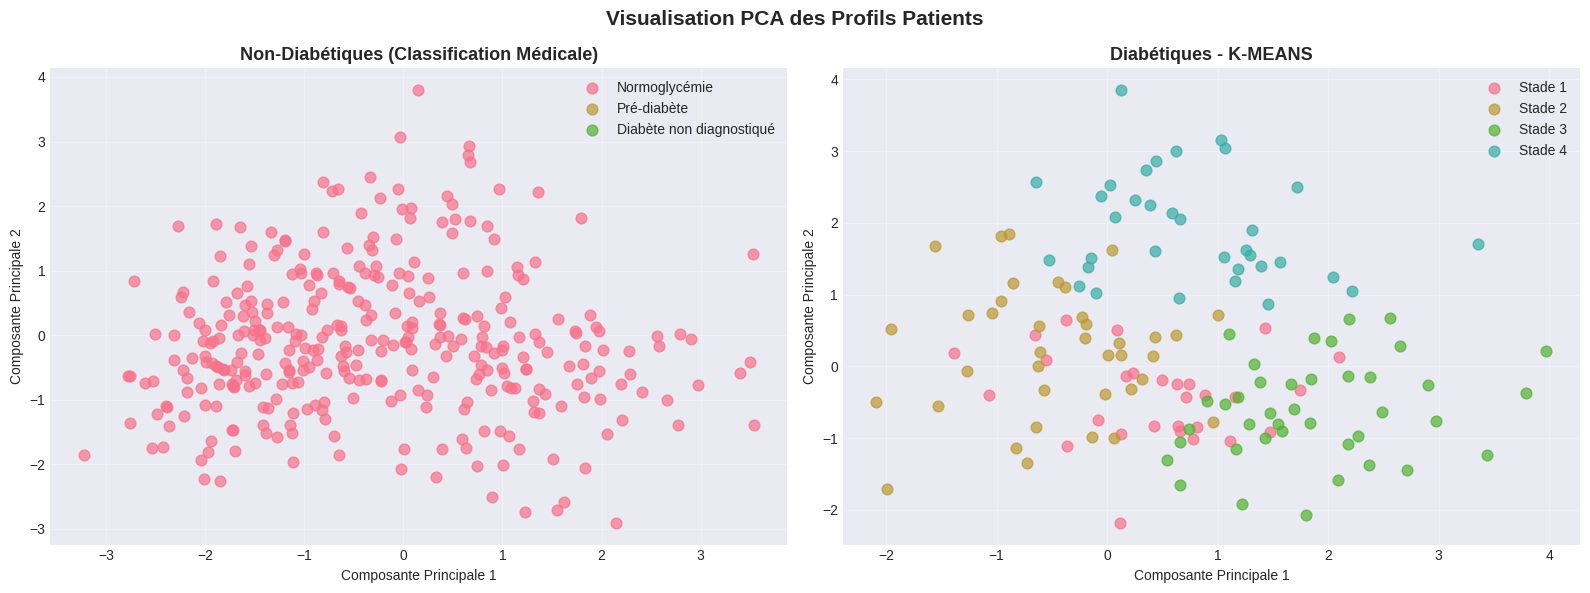

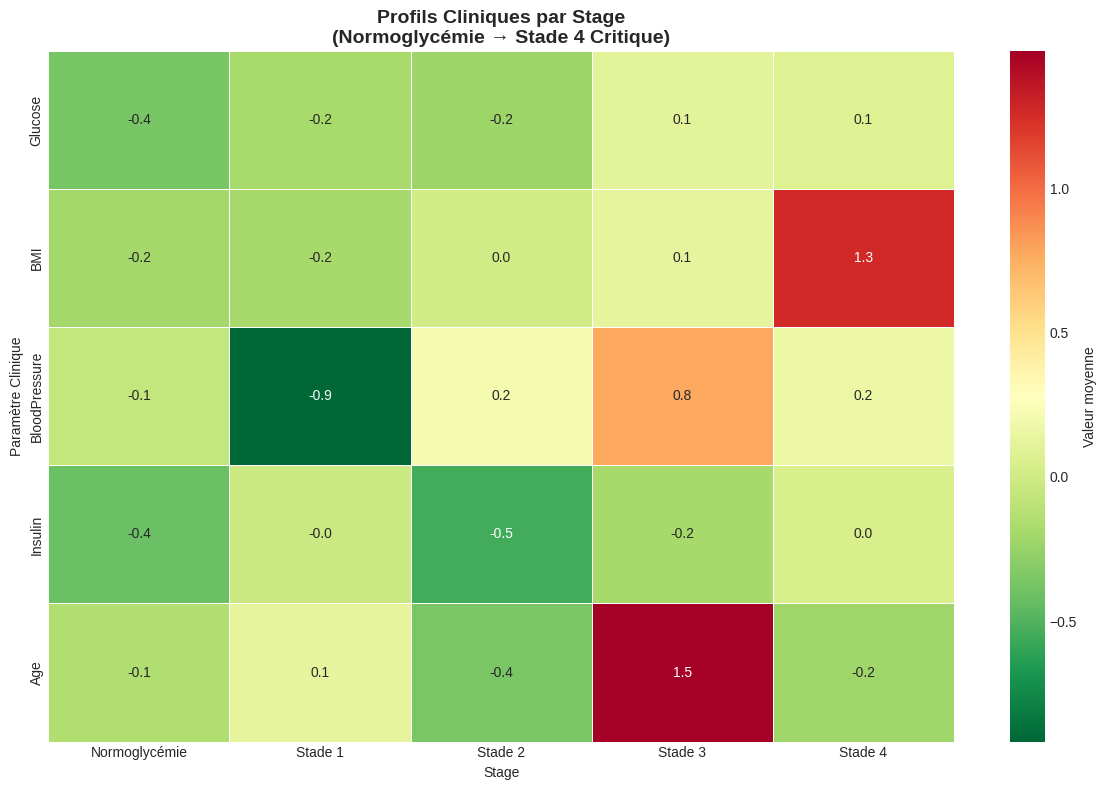

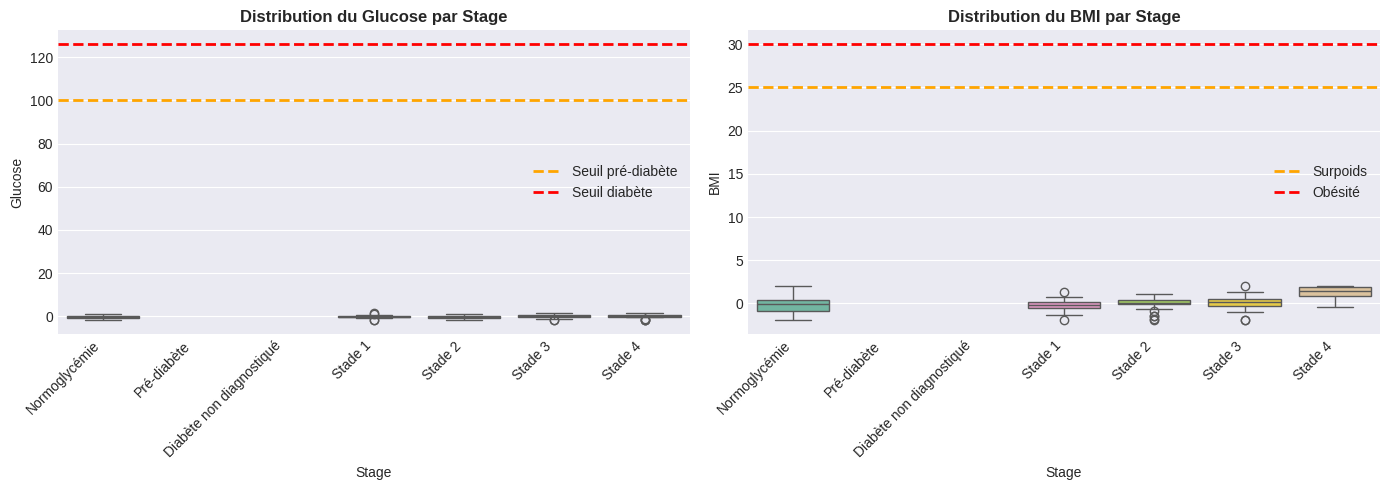


✅ Visualisations finales générées avec succès

📋 RAPPORT FINAL
Total patients: 478
Non-diabétiques: 338 (3 catégories)
Diabétiques: 140 (4 stades)
Meilleur algorithme: K-MEANS (Silhouette: 0.1318)
• Normoglycémie                 :  338 patients ( 70.7%)
• Stade 1                       :   28 patients (  5.9%)
• Stade 2                       :   38 patients (  7.9%)
• Stade 3                       :   40 patients (  8.4%)
• Stade 4                       :   34 patients (  7.1%)
Patients prioritaires: 74 (15.5%)

✅ Analyse terminée


In [18]:
# =========================================================
# BO2: CLUSTERING PROFILS PATIENTS DIABÈTE - FLAML RANDOMIZED SEARCH
# =========================================================


# ============================================================================
# CHARGEMENT DES DONNÉES
# ============================================================================
df = pd.read_csv('diabetes_cleaned_final.csv')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =========================================================
# 1. SÉPARATION DES GROUPES
# =========================================================
# Supposons que df_scaled existe déjà avec les colonnes normalisées
non_diabetic = df_scaled[df_scaled['Outcome']==0].copy()
diabetic = df_scaled[df_scaled['Outcome']==1].copy()

print(f"\n📊 Répartition initiale:")
print(f"   Non-diabétiques (Outcome=0): {len(non_diabetic)} patients")
print(f"   Diabétiques (Outcome=1): {len(diabetic)} patients")

# =========================================================
# 2. CLASSIFICATION MÉDICALE DES NON-DIABÉTIQUES
# =========================================================
def classify_non_diabetic(row):
    if row['Glucose'] < 100:
        return "Normoglycémie"
    elif row['Glucose'] < 126:
        return "Pré-diabète"
    else:
        return "Diabète non diagnostiqué"

non_diabetic['Stage'] = non_diabetic.apply(classify_non_diabetic, axis=1)

print("\n✅ Classification des non-diabétiques:")
for stage in ['Normoglycémie', 'Pré-diabète', 'Diabète non diagnostiqué']:
    count = (non_diabetic['Stage'] == stage).sum()
    pct = count / len(non_diabetic) * 100
    print(f"   • {stage:30s}: {count:4d} patients ({pct:5.1f}%)")

# =========================================================
# 3. FONCTION D'OPTIMISATION RANDOM
# =========================================================
def optimize_clustering_random(X_scaled, model_name, n_iter=20, n_stages=4, random_state=42):
    np.random.seed(random_state)
    random.seed(random_state)

    best_score = -1
    best_labels = None
    best_params = {}
    best_model = None

    for i in range(n_iter):
        if model_name == "K-MEANS":
            params = {
                'n_clusters': n_stages,
                'init': random.choice(['k-means++', 'random']),
                'n_init': random.choice([10, 20, 30]),
                'max_iter': random.choice([300, 500, 1000]),
                'algorithm': random.choice(['lloyd', 'elkan'])
            }
            model = KMeans(**params, random_state=random_state)
            labels = model.fit_predict(X_scaled)

        elif model_name == "GMM":
            params = {
                'n_components': n_stages,
                'covariance_type': random.choice(['full', 'tied', 'diag', 'spherical']),
                'init_params': random.choice(['kmeans', 'random', 'k-means++']),
                'max_iter': random.choice([100, 200, 300]),
                'n_init': random.choice([1, 5, 10])
            }
            model = GaussianMixture(**params, random_state=random_state)
            labels = model.fit_predict(X_scaled)

        elif model_name == "HIERARCHICAL":
            linkage = random.choice(['ward', 'complete', 'average', 'single'])
            metric = random.choice(['euclidean', 'manhattan', 'cosine'])
            if linkage == 'ward' and metric != 'euclidean':
                metric = 'euclidean'
            params = {'n_clusters': n_stages, 'linkage': linkage, 'metric': metric}
            model = AgglomerativeClustering(**params)
            labels = model.fit_predict(X_scaled)

        elif model_name == "DBSCAN":
            params = {
                'eps': round(random.uniform(0.3, 2.5), 2),
                'min_samples': random.choice([3, 5, 7, 10, 15, 20]),
                'metric': random.choice(['euclidean', 'manhattan', 'cosine'])
            }
            model = DBSCAN(**params)
            labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue

        try:
            score = silhouette_score(X_scaled, labels)
        except:
            continue

        if score > best_score:
            best_score = score
            best_labels = labels
            best_params = params
            best_model = model

    print(f"\n✅ {model_name} - Meilleurs Hyperparamètres trouvés:")
    for key, value in best_params.items():
        print(f"   • {key}: {value}")
    print(f"📊 Silhouette Score: {best_score:.4f}")

    return best_labels, best_score, best_params, best_model

# =========================================================
# 4. CLUSTERING DES DIABÉTIQUES
# =========================================================
X_diabetic = diabetic.drop('Outcome', axis=1).values
scaler = StandardScaler()
X_scaled_diabetic = scaler.fit_transform(X_diabetic)

models_results = {}

# KMEANS
kmeans_labels, kmeans_score, kmeans_params, kmeans_model = optimize_clustering_random(
    X_scaled_diabetic, "K-MEANS", n_iter=30, n_stages=4)
models_results['K-MEANS'] = {'labels': kmeans_labels, 'score': kmeans_score, 'params': kmeans_params, 'model': kmeans_model}

# GMM
gmm_labels, gmm_score, gmm_params, gmm_model = optimize_clustering_random(
    X_scaled_diabetic, "GMM", n_iter=30, n_stages=4)
models_results['GMM'] = {'labels': gmm_labels, 'score': gmm_score, 'params': gmm_params, 'model': gmm_model}

# HIERARCHICAL
hc_labels, hc_score, hc_params, _ = optimize_clustering_random(
    X_scaled_diabetic, "HIERARCHICAL", n_iter=30, n_stages=4)
models_results['HIERARCHICAL'] = {'labels': hc_labels, 'score': hc_score, 'params': hc_params}

# DBSCAN
dbscan_labels, dbscan_score, dbscan_params, _ = optimize_clustering_random(
    X_scaled_diabetic, "DBSCAN", n_iter=30)
models_results['DBSCAN'] = {'labels': dbscan_labels, 'score': dbscan_score, 'params': dbscan_params}

# =========================================================
# 5. SÉLECTION DU MEILLEUR MODÈLE
# =========================================================
comparison_df = pd.DataFrame({
    'Modèle': list(models_results.keys()),
    'Silhouette Score': [models_results[m]['score'] for m in models_results.keys()]
}).sort_values('Silhouette Score', ascending=False)

best_model_name = comparison_df.iloc[0]['Modèle']
best_model_score = comparison_df.iloc[0]['Silhouette Score']
diabetic['Cluster'] = models_results[best_model_name]['labels']

print(f"\n🏆 Meilleur modèle: {best_model_name} (Silhouette: {best_model_score:.4f})")
print(f"Hyperparamètres: {models_results[best_model_name]['params']}")

# =========================================================
# 6. ATTRIBUTION DES STADES MÉDICAUX
# =========================================================
cluster_profiles = diabetic.groupby('Cluster').agg({
    'Glucose': 'mean', 'BMI': 'mean', 'BloodPressure': 'mean', 'Insulin': 'mean', 'Age': 'mean'
})
cluster_profiles['RiskScore'] = (
    cluster_profiles['Glucose']*0.6 + cluster_profiles['BMI']*0.25 + cluster_profiles['BloodPressure']*0.15
)
cluster_profiles = cluster_profiles.sort_values('RiskScore')
cluster_mapping = {old: new+1 for new, old in enumerate(cluster_profiles.index)}
diabetic['Stage'] = diabetic['Cluster'].map(cluster_mapping).apply(lambda x: f"Stade {x}")

# =========================================================
# 7. COMBINAISON DES GROUPES
# =========================================================
df_final = pd.concat([non_diabetic, diabetic], axis=0)

# =========================================================
# 8. PCA POUR VISUALISATION
# =========================================================
X_all = df_final.drop(['Outcome', 'Stage'], axis=1, errors='ignore')
if 'Cluster' in df_final.columns:
    X_all = X_all.drop(['Cluster'], axis=1, errors='ignore')
X_scaled_all = scaler.fit_transform(X_all)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_all)
df_final['PC1'] = X_pca[:, 0]
df_final['PC2'] = X_pca[:, 1]

print(f"\n✅ PCA appliquée: variance expliquée = {pca.explained_variance_ratio_.sum()*100:.1f}%")

# =========================================================
# 9. VISUALISATIONS FINALES
# =========================================================
print("\n📊 Génération des visualisations finales...")

# 9.1 PCA Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-diabétiques
non_diab_plot = df_final[df_final['Outcome']==0]
for stage in ['Normoglycémie', 'Pré-diabète', 'Diabète non diagnostiqué']:
    data = non_diab_plot[non_diab_plot['Stage']==stage]
    axes[0].scatter(data['PC1'], data['PC2'], label=stage, s=60, alpha=0.7)
axes[0].set_title('Non-Diabétiques (Classification Médicale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Composante Principale 1')
axes[0].set_ylabel('Composante Principale 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Diabétiques
diab_plot = df_final[df_final['Outcome']==1]
for stage in ['Stade 1', 'Stade 2', 'Stade 3', 'Stade 4']:
    data = diab_plot[diab_plot['Stage']==stage]
    axes[1].scatter(data['PC1'], data['PC2'], label=stage, s=60, alpha=0.7)
axes[1].set_title(f'Diabétiques - {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Composante Principale 1')
axes[1].set_ylabel('Composante Principale 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Visualisation PCA des Profils Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 9.2 Heatmap des profils cliniques par Stage
features = ['Glucose', 'BMI', 'BloodPressure', 'Insulin', 'Age']
cluster_profiles_full = df_final.groupby('Stage')[features].mean()

# Réorganisation de l'ordre des stages
stage_order = ['Normoglycémie', 'Pré-diabète', 'Diabète non diagnostiqué','Stade 1','Stade 2','Stade 3','Stade 4']
cluster_profiles_full = cluster_profiles_full.reindex([s for s in stage_order if s in cluster_profiles_full.index])

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles_full.T, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Valeur moyenne'})
plt.title('Profils Cliniques par Stage\n(Normoglycémie → Stade 4 Critique)', fontsize=14, fontweight='bold')
plt.xlabel('Stage')
plt.ylabel('Paramètre Clinique')
plt.tight_layout()
plt.show()

# 9.3 Boxplots comparatifs Glucose et BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final_sorted = df_final.copy()
df_final_sorted['Stage'] = pd.Categorical(
    df_final_sorted['Stage'],
    categories=stage_order,
    ordered=True
)

# Boxplot Glucose
sns.boxplot(x='Stage', y='Glucose', data=df_final_sorted, ax=axes[0], palette='Set2')
axes[0].axhline(100, color='orange', linestyle='--', linewidth=2, label='Seuil pré-diabète')
axes[0].axhline(126, color='red', linestyle='--', linewidth=2, label='Seuil diabète')
axes[0].set_title('Distribution du Glucose par Stage', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend()

# Boxplot BMI
sns.boxplot(x='Stage', y='BMI', data=df_final_sorted, ax=axes[1], palette='Set2')
axes[1].axhline(25, color='orange', linestyle='--', linewidth=2, label='Surpoids')
axes[1].axhline(30, color='red', linestyle='--', linewidth=2, label='Obésité')
axes[1].set_title('Distribution du BMI par Stage', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n✅ Visualisations finales générées avec succès")


# =========================================================
# 10. RAPPORT FINAL
# =========================================================
print("\n📋 RAPPORT FINAL")
print(f"Total patients: {len(df_final)}")
print(f"Non-diabétiques: {len(non_diabetic)} (3 catégories)")
print(f"Diabétiques: {len(diabetic)} (4 stades)")
print(f"Meilleur algorithme: {best_model_name} (Silhouette: {best_model_score:.4f})")

stage_order = ['Normoglycémie', 'Pré-diabète', 'Diabète non diagnostiqué','Stade 1','Stade 2','Stade 3','Stade 4']
for stage in stage_order:
    if stage in df_final['Stage'].values:
        count = (df_final['Stage']==stage).sum()
        pct = count/len(df_final)*100
        print(f"• {stage:30s}: {count:4d} patients ({pct:5.1f}%)")

high_risk = df_final[df_final['Stage'].isin(['Stade 3','Stade 4','Diabète non diagnostiqué'])]
print(f"Patients prioritaires: {len(high_risk)} ({len(high_risk)/len(df_final)*100:.1f}%)")

print("\n✅ Analyse terminée")


In [19]:
#BO3: Recommander un menu

from scipy.spatial.distance import euclidean
from typing import Dict, List, Tuple


class MenuRecommendationSystem:
    def __init__(self, meal_plans_path: str, diabetes_data_path: str):
        """
        Initialise le système de recommandation de menus

        Args:
            meal_plans_path: Chemin vers meal_plans_complete.csv
            diabetes_data_path: Chemin vers diabetes_cleaned_final.csv
        """
        print("📂 Chargement des données...")
        self.meal_plans_df = pd.read_csv(meal_plans_path)
        self.diabetes_df = pd.read_csv(diabetes_data_path)

        print(f"✓ Plans de repas: {len(self.meal_plans_df)} entrées chargées")
        print(f"✓ Patients diabétiques: {len(self.diabetes_df)} patients chargés\n")

        # Normaliser les noms de colonnes (gérer Age/age)
        self._normalize_column_names()

        # Vérifier les colonnes nécessaires
        self._validate_data()

    def _normalize_column_names(self):
        """Normalise les noms de colonnes pour gérer les variations Age/age"""
        # Pour meal_plans_df
        if 'age' in self.meal_plans_df.columns and 'Age' not in self.meal_plans_df.columns:
            self.meal_plans_df.rename(columns={'age': 'Age'}, inplace=True)
            print("✓ Colonne 'age' renommée en 'Age' dans meal_plans")

        # Pour diabetes_df (normalement déjà 'Age' après cleaning)
        if 'age' in self.diabetes_df.columns and 'Age' not in self.diabetes_df.columns:
            self.diabetes_df.rename(columns={'age': 'Age'}, inplace=True)
            print("✓ Colonne 'age' renommée en 'Age' dans diabetes_df")

    def _validate_data(self):
        """Valide que les colonnes nécessaires sont présentes"""
        required_meal_cols = ['BMI', 'Age', 'meal_type', 'recipe_name']
        required_diabetes_cols = ['BMI', 'Age']

        missing_meal = []
        for col in required_meal_cols:
            if col not in self.meal_plans_df.columns:
                missing_meal.append(col)

        missing_diabetes = []
        for col in required_diabetes_cols:
            if col not in self.diabetes_df.columns:
                missing_diabetes.append(col)

        if missing_meal:
            print(f"⚠️ Colonnes manquantes dans meal_plans: {missing_meal}")
            print(f"📋 Colonnes disponibles: {list(self.meal_plans_df.columns)}")

        if missing_diabetes:
            print(f"⚠️ Colonnes manquantes dans diabetes_data: {missing_diabetes}")
            print(f"📋 Colonnes disponibles: {list(self.diabetes_df.columns)}")

        if not missing_meal and not missing_diabetes:
            print("✓ Toutes les colonnes requises sont présentes\n")

    def normalize_features(self, bmi: float, age: float) -> Tuple[float, float]:
        """
        Normalise les features BMI et Age pour la comparaison

        Args:
            bmi: BMI du patient
            age: Age du patient

        Returns:
            Tuple (bmi_normalized, age_normalized)
        """
        # Calculer les statistiques sur les plans de repas existants
        bmi_mean = self.meal_plans_df['BMI'].mean()
        bmi_std = self.meal_plans_df['BMI'].std()
        age_mean = self.meal_plans_df['Age'].mean()
        age_std = self.meal_plans_df['Age'].std()

        # Normalisation Z-score
        bmi_norm = (bmi - bmi_mean) / bmi_std if bmi_std > 0 else 0
        age_norm = (age - age_mean) / age_std if age_std > 0 else 0

        return bmi_norm, age_norm

    def find_similar_persons(self, target_bmi: float, target_age: float, n_neighbors: int = 7) -> pd.DataFrame:
        """
        Trouve les n personnes les plus similaires basées sur BMI et Age

        Args:
            target_bmi: BMI du patient cible
            target_age: Age du patient cible
            n_neighbors: Nombre de voisins à retourner

        Returns:
            DataFrame contenant les personnes similaires
        """
        # Normaliser les features du patient cible
        target_bmi_norm, target_age_norm = self.normalize_features(target_bmi, target_age)

        # Obtenir les personnes uniques dans meal_plans
        unique_persons = self.meal_plans_df.groupby(['BMI', 'Age']).first().reset_index()

        # Calculer les distances
        distances = []
        for idx, person in unique_persons.iterrows():
            person_bmi_norm, person_age_norm = self.normalize_features(
                person['BMI'],
                person['Age']
            )

            # Distance euclidienne dans l'espace normalisé
            dist = euclidean(
                [target_bmi_norm, target_age_norm],
                [person_bmi_norm, person_age_norm]
            )

            distances.append({
                'BMI': person['BMI'],
                'Age': person['Age'],
                'distance': dist
            })

        # Trier par distance et prendre les n plus proches
        distances_df = pd.DataFrame(distances)
        distances_df = distances_df.sort_values('distance').head(n_neighbors)

        return distances_df

    def get_weekly_menus_for_patient(self, target_bmi: float, target_age: float) -> Dict:
        """
        Génère les recommandations de menus pour une semaine

        Args:
            target_bmi: BMI du patient
            target_age: Age du patient

        Returns:
            Dictionnaire contenant les menus hebdomadaires
        """
        # Trouver les 7 personnes les plus similaires
        similar_persons = self.find_similar_persons(target_bmi, target_age, n_neighbors=7)

        weekly_menus = []

        # Pour chaque personne similaire, récupérer son menu quotidien complet
        for day_num, (idx, person) in enumerate(similar_persons.iterrows(), 1):
            # Filtrer les repas de cette personne
            person_meals = self.meal_plans_df[
                (self.meal_plans_df['BMI'] == person['BMI']) &
                (self.meal_plans_df['Age'] == person['Age'])
            ]

            # Organiser par type de repas
            daily_menu = {
                'day': f'Jour {day_num}',
                'person_bmi': person['BMI'],
                'person_age': person['Age'],
                'similarity_score': 100 - (person['distance'] * 10),  # Score de similarité
                'meals': {}
            }

            # Grouper par type de repas
            for meal_type in ['Petit-déjeuner', 'Déjeuner', 'Dîner', 'Collation']:
                meal_recipes = person_meals[person_meals['meal_type'] == meal_type]

                if len(meal_recipes) > 0:
                    recipes_info = []
                    for _, recipe in meal_recipes.iterrows():
                        recipes_info.append({
                            'name': recipe.get('recipe_name', 'N/A'),
                            'calories': recipe.get('recipe_calories', 0),
                            'protein': recipe.get('protein_content', 0),
                            'sugar': recipe.get('sugar_content', 0),
                            'instructions': recipe.get('recipe_instructions', '')
                        })

                    daily_menu['meals'][meal_type] = recipes_info

            weekly_menus.append(daily_menu)

        return {
            'patient_bmi': target_bmi,
            'patient_age': target_age,
            'weekly_menus': weekly_menus
        }

    def format_recommendation_output(self, patient_bmi: float, patient_age: float) -> str:
        """
        Formate la sortie de recommandation de manière lisible

        Args:
            patient_bmi: BMI du patient
            patient_age: Age du patient

        Returns:
            String formatée avec les recommandations
        """
        recommendations = self.get_weekly_menus_for_patient(patient_bmi, patient_age)

        output = []
        output.append("=" * 80)
        output.append("🍽️  RECOMMANDATION DE MENUS HEBDOMADAIRES")
        output.append("=" * 80)
        output.append(f"\n📊 Profil du patient:")
        output.append(f"   • BMI: {patient_bmi:.1f}")
        output.append(f"   • Âge: {patient_age:.0f} ans")
        output.append(f"\n💡 Selon votre âge et votre BMI, je vous recommande ces 7 menus pour la semaine:\n")

        for day_menu in recommendations['weekly_menus']:
            output.append("─" * 80)
            output.append(f"\n📅 {day_menu['day'].upper()}")
            output.append(f"   Profil similaire: BMI={day_menu['person_bmi']:.1f}, Âge={day_menu['person_age']:.0f}")
            output.append(f"   Score de similarité: {day_menu['similarity_score']:.1f}%\n")

            for meal_type, recipes in day_menu['meals'].items():
                output.append(f"   🍴 {meal_type}:")

                for recipe in recipes:
                    output.append(f"      • {recipe['name']}")
                    output.append(f"        - Calories: {recipe['calories']:.0f} kcal")
                    output.append(f"        - Protéines: {recipe['protein']:.1f}g")
                    output.append(f"        - Sucres: {recipe['sugar']:.1f}g")

                    if recipe['instructions']:
                        # Limiter la longueur des instructions pour l'affichage
                        instructions = recipe['instructions'][:150]
                        if len(recipe['instructions']) > 150:
                            instructions += "..."
                        output.append(f"        - Instructions: {instructions}")
                    output.append("")

        output.append("=" * 80)
        output.append("✅ Plan nutritionnel personnalisé généré avec succès!")
        output.append("=" * 80)

        return "\n".join(output)

    def recommend_for_all_patients(self, output_csv: str = 'patient_recommendations.csv'):
        """
        Génère des recommandations pour tous les patients diabétiques

        Args:
            output_csv: Chemin du fichier CSV de sortie
        """
        print("🔄 Génération des recommandations pour tous les patients...\n")

        all_recommendations = []
        total_patients = len(self.diabetes_df)

        for idx, patient in self.diabetes_df.iterrows():
            if (idx + 1) % 10 == 0:
                print(f"Progression: {idx + 1}/{total_patients} patients traités...")

            patient_bmi = patient.get('BMI')
            patient_age = patient.get('Age')

            if pd.isna(patient_bmi) or pd.isna(patient_age):
                continue

            # Obtenir les recommandations
            reco = self.get_weekly_menus_for_patient(patient_bmi, patient_age)

            # Créer une ligne pour chaque jour de la semaine
            for day_menu in reco['weekly_menus']:
                for meal_type, recipes in day_menu['meals'].items():
                    for recipe in recipes:
                        all_recommendations.append({
                            'patient_id': idx,
                            'patient_bmi': patient_bmi,
                            'patient_age': patient_age,
                            'day': day_menu['day'],
                            'similarity_score': day_menu['similarity_score'],
                            'meal_type': meal_type,
                            'recipe_name': recipe['name'],
                            'recipe_calories': recipe['calories'],
                            'protein_content': recipe['protein'],
                            'sugar_content': recipe['sugar'],
                            'recipe_instructions': recipe['instructions']
                        })

        # Sauvegarder dans un CSV
        recommendations_df = pd.DataFrame(all_recommendations)
        recommendations_df.to_csv(output_csv, index=False)

        print(f"\n✅ Recommandations générées: {len(recommendations_df)} entrées")
        print(f"💾 Fichier sauvegardé: {output_csv}\n")

        return recommendations_df


# ============================================================================
# EXEMPLE D'UTILISATION DANS GOOGLE COLAB
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("🏥 SYSTÈME DE RECOMMANDATION DE MENUS POUR PATIENTS DIABÉTIQUES")
    print("=" * 80)
    print()

    # ÉTAPE 1: Charger les fichiers
    meal_plans_file = "meal_plans_complete.csv"
    diabetes_file = "diabetes_cleaned_final.csv"  # Corrigé: diabetes_cleaned_final.csv

    # Créer le système de recommandation
    recommender = MenuRecommendationSystem(meal_plans_file, diabetes_file)

    # ========================================================================
    # Exemple: Recommandation pour UN patient spécifique
    # ========================================================================
    print("\n📋 OPTION 1: Recommandation pour un patient spécifique\n")

    # Exemple: Patient avec BMI=28.5 et Age=45
    patient_bmi = 28.5
    patient_age = 45

    # Afficher la recommandation formatée
    recommendation_text = recommender.format_recommendation_output(patient_bmi, patient_age)
    print(recommendation_text)



    # ========================================================================
    # Télécharger les résultats
    # ========================================================================
    print("\n💡 Pour télécharger les fichiers dans Colab:")
    print("   from google.colab import files")
    print("   files.download('patient_recommendations.csv')")

🏥 SYSTÈME DE RECOMMANDATION DE MENUS POUR PATIENTS DIABÉTIQUES

📂 Chargement des données...
✓ Plans de repas: 42904 entrées chargées
✓ Patients diabétiques: 478 patients chargés

✓ Colonne 'age' renommée en 'Age' dans meal_plans
✓ Toutes les colonnes requises sont présentes


📋 OPTION 1: Recommandation pour un patient spécifique

🍽️  RECOMMANDATION DE MENUS HEBDOMADAIRES

📊 Profil du patient:
   • BMI: 28.5
   • Âge: 45 ans

💡 Selon votre âge et votre BMI, je vous recommande ces 7 menus pour la semaine:

────────────────────────────────────────────────────────────────────────────────

📅 JOUR 1
   Profil similaire: BMI=30.1, Âge=37
   Score de similarité: 95.1%

   🍴 Petit-déjeuner:
      • Cola Cake
        - Calories: 561 kcal
        - Protéines: 6.1g
        - Sucres: 52.8g
        - Instructions: c("Beat all but eggs and marshmallows for two minutes.", "Add eggs and beat two minutes more.  Stir in marshmallows.", "Bake in 9 X 13 pan for 35 minu...

   🍴 Déjeuner:
      • Chocolate 